## Face Mask Detection using CNN

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import itertools
import cv2

#### Paths & Config

In [2]:
BASE_DIR = os.path.abspath('.') 
DATA_DIR = os.path.join(BASE_DIR, 'data') 
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 25
SEED = 42


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)


Found 7553 images belonging to 2 classes.
Found 7553 images belonging to 2 classes.
Found 7553 images belonging to 2 classes.


#### Build CNN Model

In [4]:
def build_cnn(input_shape=IMG_SIZE + (3,)):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out)
    return model

model = build_cnn()
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 4,289,217 (16.36 MB)

 Trainable params: 4,288,513 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

#### Callbacks & Train

In [5]:
checkpoint_path = os.path.join(MODEL_DIR, 'best_mask_detector.h5')
cb = [
    callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss'),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=cb
)

# Save final model
final_model_path = os.path.join(MODEL_DIR, 'final_mask_detector.h5')
model.save(final_model_path)
print("Saved final model to:", final_model_path)


C:\Users\steve\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
204/237 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.8330 - loss: 0.4498

C:\Users\steve\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8380 - loss: 0.4338

237/237 ━━━━━━━━━━━━━━━━━━━━ 116s 472ms/step - accuracy: 0.8703 - loss: 0.3300 - val_accuracy: 0.6965 - val_loss: 0.5960
Epoch 2/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9009 - loss: 0.2345

...

237/237 ━━━━━━━━━━━━━━━━━━━━ 143s 477ms/step - accuracy: 0.9580 - loss: 0.1100 - val_accuracy: 0.9697 - val_loss: 0.0791
Epoch 11/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 112s 472ms/step - accuracy: 0.9639 - loss: 0.0992 - val_accuracy: 0.9711 - val_loss: 0.0838
Epoch 12/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9590 - loss: 0.1037

237/237 ━━━━━━━━━━━━━━━━━━━━ 112s 474ms/step - accuracy: 0.9617 - loss: 0.1029 - val_accuracy: 0.9695 - val_loss: 0.0752
Epoch 13/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9651 - loss: 0.0959

237/237 ━━━━━━━━━━━━━━━━━━━━ 112s 471ms/step - accuracy: 0.9658 - loss: 0.0945 - val_accuracy: 0.9772 - val_loss: 0.0678
Epoch 14/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 144s 479ms/step - accuracy: 0.9664 - loss: 0.0902 - val_accuracy: 0.9640 - val_loss: 0.0951
Epoch 15/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 110s 463ms/step - accuracy: 0.9699 - loss: 0.0905 - val_accuracy: 0.9723 - val_loss: 0.0724
Epoch 16/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9737 - loss: 0.0716

237/237 ━━━━━━━━━━━━━━━━━━━━ 110s 465ms/step - accuracy: 0.9713 - loss: 0.0756 - val_accuracy: 0.9872 - val_loss: 0.0368
Epoch 17/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 109s 461ms/step - accuracy: 0.9705 - loss: 0.0771 - val_accuracy: 0.9063 - val_loss: 0.2154
Epoch 18/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 143s 466ms/step - accuracy: 0.9707 - loss: 0.0782 - val_accuracy: 0.9853 - val_loss: 0.0436
Epoch 19/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 113s 475ms/step - accuracy: 0.9747 - loss: 0.0736 - val_accuracy: 0.9824 - val_loss: 0.0622
Epoch 20/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 110s 465ms/step - accuracy: 0.9750 - loss: 0.0740 - val_accuracy: 0.9809 - val_loss: 0.0466
Epoch 21/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 109s 460ms/step - accuracy: 0.9762 - loss: 0.0668 - val_accuracy: 0.9090 - val_loss: 0.2238
Epoch 22/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 111s 468ms/step - accuracy: 0.9743 - loss: 0.0702 - val_accuracy: 0.9677 - val_loss: 0.0820


Saved final model to: C:\Users\steve\Documents\UPGRAD\DEEP LEARNING\CA\models\final_mask_detector.h5


#### Plot Training Curves

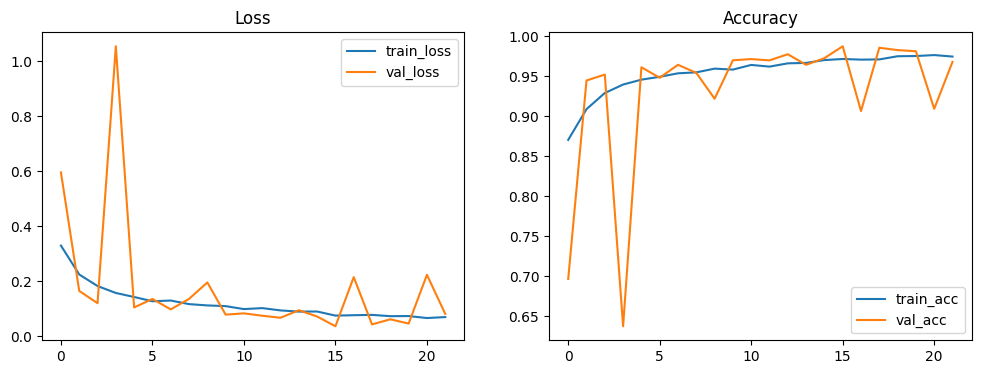

In [6]:
def plot_history(h):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.legend()
    plt.title('Loss')

    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.legend()
    plt.title('Accuracy')
    plt.show()

plot_history(history)


#### Evaluate on Test Set

In [7]:
model = load_model(checkpoint_path)

# Predict on test set
steps = int(np.ceil(test_gen.samples / test_gen.batch_size))
preds = model.predict(test_gen, steps=steps, verbose=1)
y_pred = (preds.ravel() > 0.5).astype(int)
y_true = test_gen.classes[:len(y_pred)]
class_labels = list(test_gen.class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


237/237 ━━━━━━━━━━━━━━━━━━━━ 71s 298ms/step
Classification Report:
              precision    recall  f1-score   support

   with_mask       0.98      0.99      0.99      3725
without_mask       0.99      0.98      0.99      3828

    accuracy                           0.99      7553
   macro avg       0.99      0.99      0.99      7553
weighted avg       0.99      0.99      0.99      7553

Confusion Matrix:
 [[3704   21]
 [  76 3752]]


#### Confusion Matrix Plot

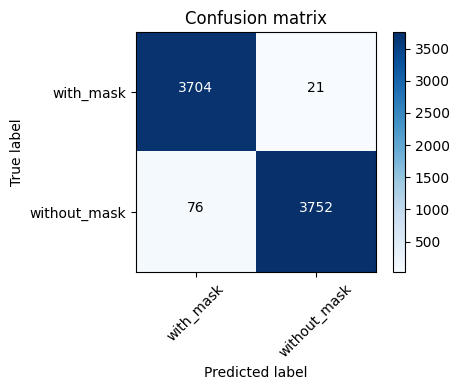

In [8]:
def plot_confusion_matrix(cm, classes, title='Confusion matrix'):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_labels)


#### Single Image Inference

In [9]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(img_path, model, target_size=IMG_SIZE):
    img = load_img(img_path, target_size=target_size)
    arr = img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)[0][0]
    label = "with_mask" if pred <= 0.5 else "without_mask"
    return pred, label


#### Real-time Webcam Inference 

In [ ]:
# Cell 13: Webcam inference (optional). Note: may not work in some notebook environments.
# Uses OpenCV Haar cascade for face detection. For better results use cv2.dnn or MTCNN.

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
model = load_model(checkpoint_path)

def run_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Cannot open webcam")
        return
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60,60))
        for (x,y,w,h) in faces:
            face = frame[y:y+h, x:x+w]
            face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face_resized = cv2.resize(face_rgb, IMG_SIZE)
            face_arr = face_resized.astype('float32') / 255.0
            face_input = np.expand_dims(face_arr, axis=0)
            pred = model.predict(face_input)[0][0]
            label = "Mask" if pred <= 0.5 else "No Mask"
            color = (0,255,0) if label == "Mask" else (0,0,255)
            text = f"{label}: {pred:.2f}"
            cv2.putText(frame, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            cv2.rectangle(frame, (x,y), (x+w, y+h), color, 2)
        cv2.imshow('Mask Detector', frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

# To run: uncomment the following line in a local environment (won't work in headless remote)
run_webcam()
